In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [26]:
df=pd.read_csv('/content/diabetic_data.csv')
mapping = pd.read_csv('/content/IDS_mapping.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
print("Shape:", df.shape)

Shape: (101766, 50)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [7]:
# In this dataset missing values are marked as '?' not NaN
# Replace all '?' with NaN first
df.replace('?', np.nan, inplace=True)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

                   Missing Count  Missing %
weight                     98569  96.858479
max_glu_serum              96420  94.746772
A1Cresult                  84748  83.277322
medical_specialty          49949  49.082208
payer_code                 40256  39.557416
race                        2273   2.233555
diag_3                      1423   1.398306
diag_2                       358   0.351787
diag_1                        21   0.020636


In [8]:
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
df.drop(columns=cols_to_drop, inplace=True)
print("Columns after drop:", df.shape)

Columns after drop: (101766, 45)


In [9]:
df['race'].fillna('Unknown', inplace=True)
df.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)
print("Final shape:", df.shape)
print("Overall null sum :",df.isnull().sum().sum())

Final shape: (100244, 45)
Overall null sum : 0


In [10]:
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)
print("Shape after dropping IDs:", df.shape)

Shape after dropping IDs: (100244, 43)


In [11]:
print(df['gender'].value_counts())

gender
Female             53922
Male               46319
Unknown/Invalid        3
Name: count, dtype: int64


In [12]:
df = df[df['gender'] != 'Unknown/Invalid']
print("Final clean shape:", df.shape)

Final clean shape: (100241, 43)


In [13]:
print(df['readmitted'].value_counts())
print("\nReadmission %:")
print(df['readmitted'].value_counts(normalize=True) * 100)

readmitted
NO     53818
>30    35173
<30    11250
Name: count, dtype: int64

Readmission %:
readmitted
NO     53.688610
>30    35.088437
<30    11.222953
Name: proportion, dtype: float64


In [14]:
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df['readmitted_any'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)
print(df[['readmitted', 'readmitted_binary', 'readmitted_any']].head(10))

   readmitted  readmitted_binary  readmitted_any
1         >30                  0               1
2          NO                  0               0
3          NO                  0               0
4          NO                  0               0
5         >30                  0               1
6          NO                  0               0
7         >30                  0               1
8          NO                  0               0
9          NO                  0               0
10        >30                  0               1


In [15]:
print(df['age'].value_counts().sort_index())

age
[0-10)         65
[10-20)       469
[20-30)      1515
[30-40)      3616
[40-50)      9474
[50-60)     17044
[60-70)     22287
[70-80)     25896
[80-90)     17090
[90-100)     2785
Name: count, dtype: int64


In [16]:
df.to_csv('diabetic_data_clean.csv', index=False)
print("Clean file saved successfully!")
print("Final shape:", df.shape)

Clean file saved successfully!
Final shape: (100241, 45)


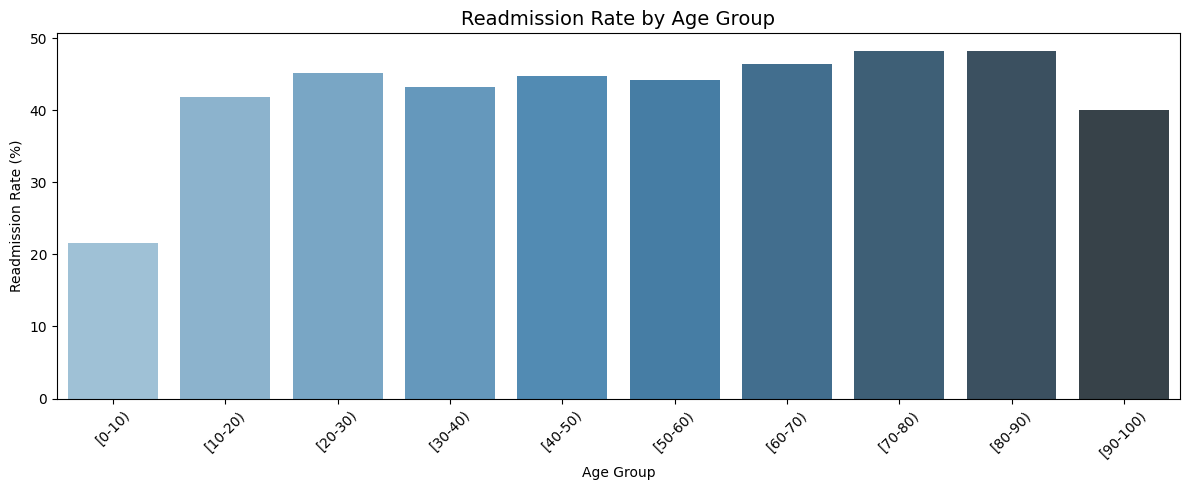

age
[0-10)      21.538462
[10-20)     41.791045
[20-30)     45.148515
[30-40)     43.252212
[40-50)     44.806840
[50-60)     44.226707
[60-70)     46.376812
[70-80)     48.208217
[80-90)     48.262142
[90-100)    40.000000
Name: readmitted_any, dtype: float64


In [17]:
plt.figure(figsize=(12, 5))
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_readmit = df.groupby('age')['readmitted_any'].mean() * 100
age_readmit = age_readmit.reindex(age_order)
sns.barplot(x=age_readmit.index, y=age_readmit.values, palette='Blues_d')
plt.title('Readmission Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_age_readmission.png', dpi=150)
plt.show()
print(age_readmit)

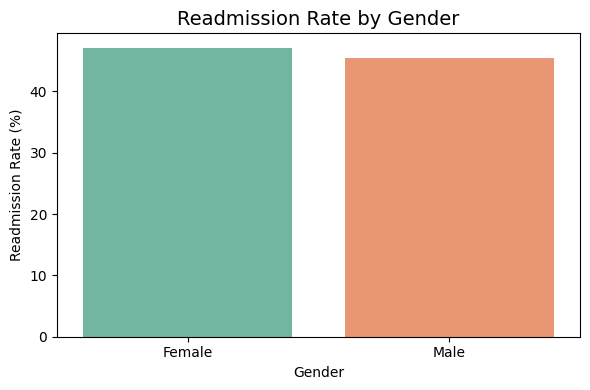

gender
Female    47.112496
Male      45.378786
Name: readmitted_any, dtype: float64


In [18]:
plt.figure(figsize=(6, 4))

gender_readmit = df.groupby('gender')['readmitted_any'].mean() * 100

sns.barplot(x=gender_readmit.index, y=gender_readmit.values, palette='Set2')
plt.title('Readmission Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('chart2_gender_readmission.png', dpi=150)
plt.show()
print(gender_readmit)

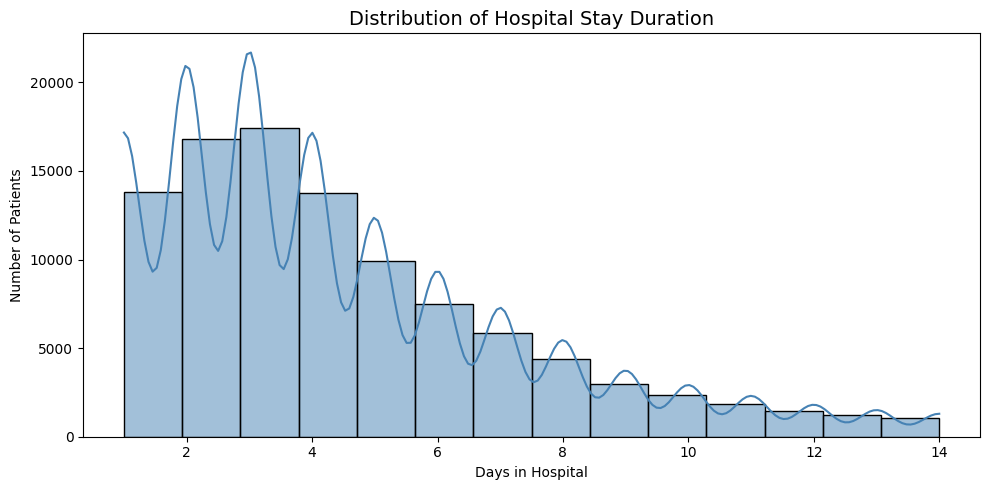

count    100241.000000
mean          4.420307
std           2.991258
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(df['time_in_hospital'], bins=14, kde=True, color='steelblue')
plt.title('Distribution of Hospital Stay Duration', fontsize=14)
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('chart3_hospital_stay.png', dpi=150)
plt.show()
print(df['time_in_hospital'].describe())

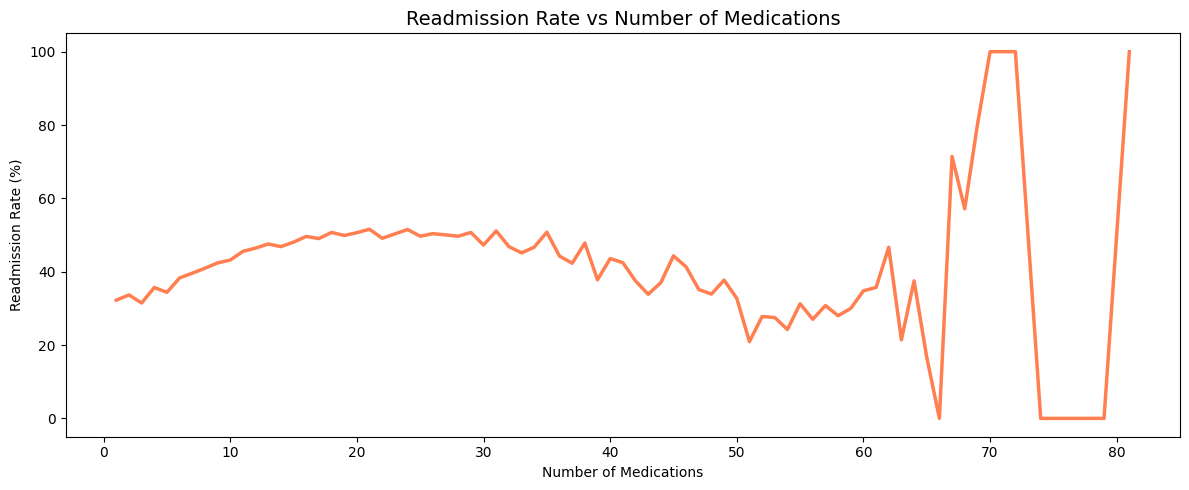

In [20]:
plt.figure(figsize=(12, 5))
med_readmit = df.groupby('num_medications')['readmitted_any'].mean() * 100
sns.lineplot(x=med_readmit.index, y=med_readmit.values, color='coral', linewidth=2.5)
plt.title('Readmission Rate vs Number of Medications', fontsize=14)
plt.xlabel('Number of Medications')
plt.ylabel('Readmission Rate (%)')
plt.tight_layout()
plt.savefig('chart4_medications_readmission.png', dpi=150)
plt.show()

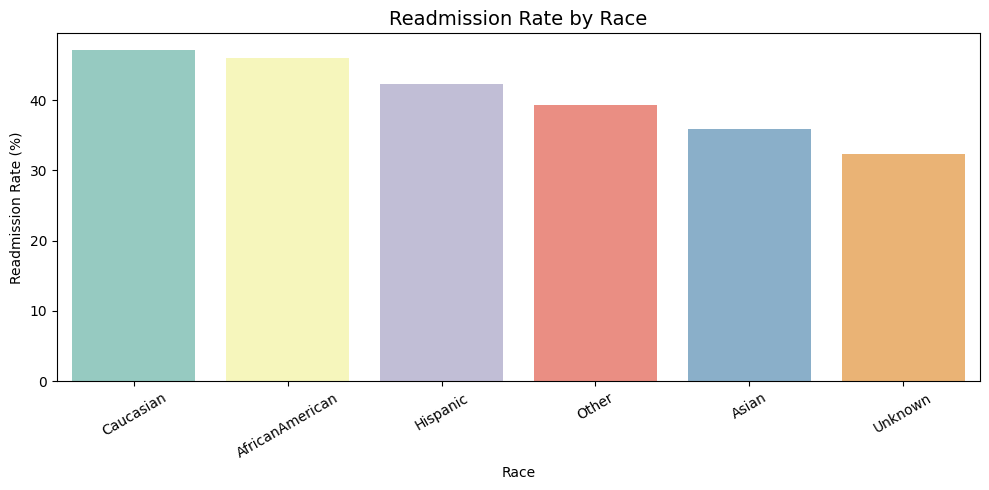

race
Caucasian          47.131688
AfricanAmerican    45.988030
Hispanic           42.338710
Other              39.244774
Asian              35.840000
Unknown            32.343536
Name: readmitted_any, dtype: float64


In [21]:
plt.figure(figsize=(10, 5))

race_readmit = df.groupby('race')['readmitted_any'].mean() * 100
race_readmit = race_readmit.sort_values(ascending=False)

sns.barplot(x=race_readmit.index, y=race_readmit.values, palette='Set3')
plt.title('Readmission Rate by Race', fontsize=14)
plt.xlabel('Race')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart5_race_readmission.png', dpi=150)
plt.show()
print(race_readmit)

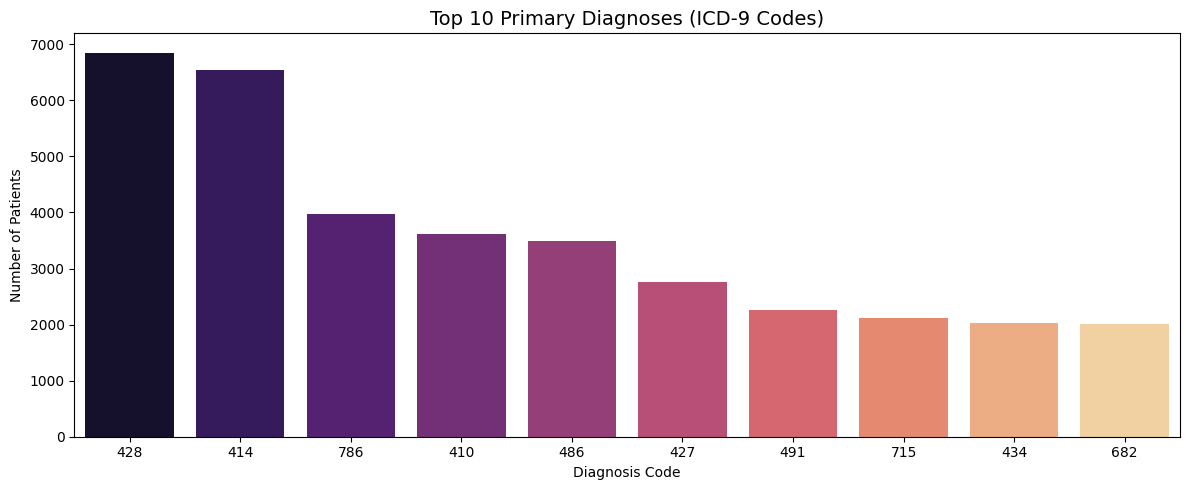

diag_1
428    6853
414    6545
786    3977
410    3610
486    3495
427    2755
491    2257
715    2123
434    2021
682    2012
Name: count, dtype: int64


In [22]:
plt.figure(figsize=(12, 5))

top_diag = df['diag_1'].value_counts().head(10)

sns.barplot(x=top_diag.index, y=top_diag.values, palette='magma')
plt.title('Top 10 Primary Diagnoses (ICD-9 Codes)', fontsize=14)
plt.xlabel('Diagnosis Code')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('chart6_top_diagnoses.png', dpi=150)
plt.show()
print(top_diag)

In [23]:
!pip install sqlalchemy mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 64.7 MB/s eta 0:00:00
